# Stochastic, equilibrium, and post-selected spectra
Matched hard-wall states at $N_x=20$, $N_y=24,28,32,40,50,60$, with 100 independent stochastic trajectories at each size. This notebook tests spectral shape, update-order/cut-position dependence, level splitting, spatial entropy, and finite-size scaling. It reads validated products from the companion CPU scripts. Existing production inputs and previous figures remain unchanged.

In [1]:
import os
if 'AVAILABLE_CPUS' not in globals():
    AVAILABLE_CPUS=sorted(os.sched_getaffinity(0))
CPU_RANGE=(AVAILABLE_CPUS[0], AVAILABLE_CPUS[min(3,len(AVAILABLE_CPUS)-1)])
selected=list(range(CPU_RANGE[0],CPU_RANGE[1]+1))
assert set(selected).issubset(AVAILABLE_CPUS)
os.sched_setaffinity(0,selected)
for key in ('OPENBLAS_NUM_THREADS','MKL_NUM_THREADS','OMP_NUM_THREADS'):
    os.environ[key]=str(len(selected))
from threadpoolctl import threadpool_limits
limits=threadpool_limits(len(selected))
print('Allocated CPUs:',selected)

Allocated CPUs: [0, 1, 2, 3]


## Estimators and comparison contract
Write $G_{ij}=\langle\hat\psi_i^\dagger\hat\psi_j\rangle$ for the occupation correlation matrix and $Q_A=2G_A-\mathbf{1}_A$ for its centered restriction. The previous cache calls $Q_A$ the centered covariance `G`. Each physical trajectory is a pure projector, but its restriction is mixed. The half subsystem contains every $x$, both orbitals, and $N_y/2$ consecutive rows, using $i=2N_xy+2x+\mu$.

For $\nu=(1+\lambda)/2$, the single-particle entanglement energy is
$$\epsilon=\log[(1-\nu)/\nu]=-2\operatorname{arctanh}\lambda,$$
so
$$\rho_Q(\lambda)=\frac{2\rho_\epsilon(-2\operatorname{arctanh}\lambda)}{1-\lambda^2}.$$
A constant entanglement-energy density therefore has a U-shaped covariance-density envelope, including a flat expansion near zero. The bin-free count $N(|\lambda|<a)$ is proportional to $\operatorname{arctanh}a$ for this envelope, versus $a$ for a constant covariance density. Fits below are descriptive, with no assumption that eigenvalues or thresholds are independent samples.

Entropy and intrinsic charge variance are computed **within each trajectory** before averaging:
$$S_A=-\sum_j[\nu_j\log\nu_j+(1-\nu_j)\log(1-\nu_j)],\qquad V_A=\sum_j\nu_j(1-\nu_j).$$
For ideal continuum densities extending over their full natural support, $S_A/V_A=3$ for constant covariance density, and $\pi^2/3$ for constant entanglement-energy density. These are shape benchmarks, not proofs of universality.

The equilibrium reference is the half-filled ground state of the sum of normalized overcomplete Wannier (OW) projectors, not the spectrum of $\operatorname{sgn}H$. An ordered product of noncommuting forced measurements need not have that same fixed point. We keep postselection separate.

Sources: [Peschel and Eisler](https://arxiv.org/abs/0906.1663) for free-fermion reduced states; [Song et al.](https://arxiv.org/abs/1008.5191) for entropy and charge statistics.

In [2]:
from pathlib import Path
import sys,json,hashlib,subprocess
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display,Image,Markdown
from tqdm.auto import tqdm
OUT=Path.cwd()
if not (OUT/'matched_spectra.npz').exists():
    root=next(p for p in (OUT,*OUT.parents) if (p/'PROJECT_ADMIN/REPO_POLICY.md').exists())
    OUT=root/'00_WORKSPACE/CURRENT/final_production_new_designs/09_pure_tangent_replay_acquisition/analysis_outputs/stochastic_equilibrium_spectral_comparison_v1'
sys.path.insert(0,str(OUT))
from analyze_comparison import metrics,ms
BINS=50
MIXED_TOL=1e-8
DISPLAY_NY=32
sizes=[24,28,32,40,50,60]
small=dict(np.load(OUT/'matched_spectra.npz'))
large=dict(np.load(OUT/'extended_size_controls.npz'))
spatial=dict(np.load(OUT/'spatial_and_origin_controls_all100.npz'))
findings=json.loads((OUT/'findings.json').read_text())
counts=dict(np.load(OUT/'bin_free_spectral_counts.npz'))
size_table=pd.read_csv(OUT/'size_summary.csv')
print(json.dumps({'Nx':20,'Ny':sizes,'samples_per_size':100,'cycles':'2*Ny','walls':[5,15],
 'alpha_1':1,'alpha_2':30,'nshell':1,'initialization':'pure, exterior prepared as a product',
 'stochastic_protocol':'perfect correction; hard/support-truncated; slab-only measurements; raster_y',
 'origin_control_Ny32':'all 100 trajectories, all 16 inequivalent cuts',
 'origin_control_Ny40_50_60':'20 trajectories per size, all Ny/2 inequivalent cuts',
 'uncertainty':'trajectory SEM; average cut origins inside each trajectory first',
 'normalization':'each density normalized over abs(lambda)<1-MIXED_TOL'},indent=2))
display(size_table[['Ny','protocol','S1','S_sem','V','S_over_V']])
os.environ['TEXINPUTS']=str(OUT/'latex_support')+os.pathsep+os.environ.get('TEXINPUTS','')
mpl.rcParams.update({'font.family':'sans-serif','font.sans-serif':['CMU Sans Serif'],
 'font.size':8,'axes.labelsize':8,'axes.titlesize':8,'xtick.labelsize':8,'ytick.labelsize':8,
 'text.usetex':True,'pdf.fonttype':42,'xtick.direction':'in','ytick.direction':'in'})
RED='#c62828';BLUE='#1565c0';GREEN='#2e7d32'
def export(fig,name):
    for ax in fig.axes: ax.tick_params(top=True,right=True)
    fig.tight_layout(pad=.7)
    fig.savefig(OUT/(name+'.pdf'));plt.close(fig)
    subprocess.run(['pdftoppm','-r','300','-singlefile','-png',str(OUT/(name+'.pdf')),str(OUT/name)],check=True)
    display(Image(filename=str(OUT/(name+'.png')),width=900 if len(fig.axes)>1 else 550))
def label(ax,letter):ax.text(-.14,1.03,letter,transform=ax.transAxes,fontweight='bold')
def density(a,edges,transform=False):
    a=np.atleast_2d(a);ret=[r[abs(r)<1-MIXED_TOL] for r in a]
    totals=np.array([len(r) for r in ret]);hist=np.array([np.histogram(-2*np.arctanh(r) if transform else r,edges)[0] for r in ret])
    widths=np.diff(edges);rho=hist.sum(0)/(totals.sum()*widths)
    influence=(hist-rho[None,:]*widths*totals[:,None])/(totals.mean()*widths)
    se=influence.std(0,ddof=1)/np.sqrt(len(a)) if len(a)>1 else np.zeros_like(rho)
    return rho,se,hist.sum(0)


{
  "Nx": 20,
  "Ny": [
    24,
    28,
    32,
    40,
    50,
    60
  ],
  "samples_per_size": 100,
  "cycles": "2*Ny",
  "walls": [
    5,
    15
  ],
  "alpha_1": 1,
  "alpha_2": 30,
  "nshell": 1,
  "initialization": "pure, exterior prepared as a product",
  "stochastic_protocol": "perfect correction; hard/support-truncated; slab-only measurements; raster_y",
  "origin_control_Ny32": "all 100 trajectories, all 16 inequivalent cuts",
  "origin_control_Ny40_50_60": "20 trajectories per size, all Ny/2 inequivalent cuts",
  "uncertainty": "trajectory SEM; average cut origins inside each trajectory first",
  "normalization": "each density normalized over abs(lambda)<1-MIXED_TOL"
}


,Ny,protocol,S1,S_sem,V,S_over_V
0,24,stochastic,9.711778,0.022160,2.974428,3.265091
1,24,equilibrium,9.016347,NaN,2.740624,3.289889
2,28,stochastic,9.787489,0.022512,2.996985,3.265778
3,28,equilibrium,9.067910,NaN,2.756302,3.289882
4,32,stochastic,9.783876,0.018410,2.995989,3.265659
5,32,equilibrium,9.112538,NaN,2.769871,3.289878
6,40,stochastic,9.912531,0.019298,3.035969,3.265030
7,40,equilibrium,9.187056,NaN,2.792525,3.289874
8,40,quarter_cut,9.382859,0.023966,2.865918,3.273945
9,50,stochastic,9.969083,0.018642,3.052434,3.265946


## Equal normalization and the change of spectral variable
The left panel uses identical bins and endpoint filtering. The right panel shows a central window of the transformed spectrum, with the same retained-mode normalization; probability outside the window is not renormalized away. Empty bins remain gaps on the log scale. No smoothing kernel is used.

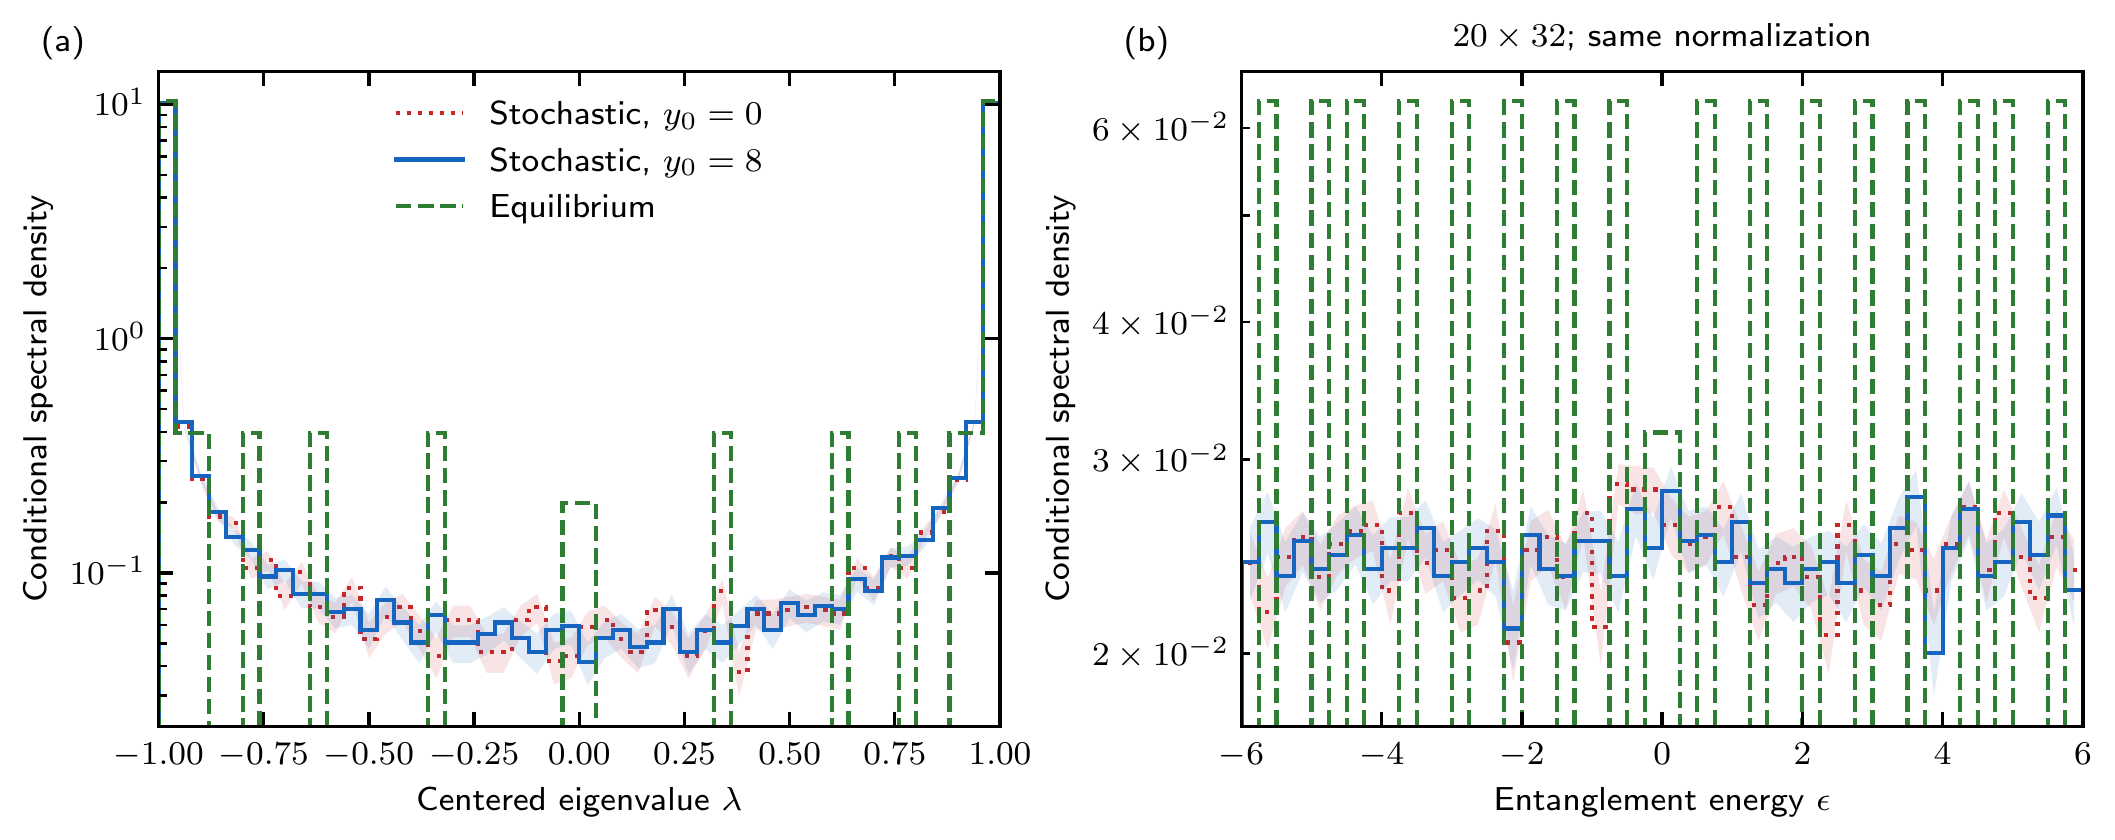

In [3]:
fig,axes=plt.subplots(1,2,figsize=(7.05,2.8))
if DISPLAY_NY==32:
    series=[('Stochastic, $y_0=0$',spatial['y0_spectra'],RED,':'),
            ('Stochastic, $y_0=8$',spatial['y8_spectra'],BLUE,'-'),
            ('Equilibrium',spatial['equilibrium_eigenvalues'][None,:],GREEN,'--')]
else:
    bank=small if DISPLAY_NY<40 else large
    series=[('Stochastic',bank[f'stochastic_{DISPLAY_NY}'],RED,':'),('Equilibrium',bank[f'equilibrium_{DISPLAY_NY}'],GREEN,'--')]
rows=[]
for j,(edges,transform) in enumerate([(np.linspace(-1,1,BINS+1),False),(np.linspace(-6,6,49),True)]):
    ax=axes[j]
    for name,a,color,style in series:
        rho,se,h=density(a,edges,transform)
        ax.stairs(np.where(h>0,rho,np.nan),edges,label=name,color=color,linestyle=style,lw=1)
        if len(a)>1:
            centers=(edges[:-1]+edges[1:])/2
            ax.fill_between(centers,np.where(rho>se,rho-se,np.nan),rho+se,color=color,alpha=.12,linewidth=0)
        for lo,hi,r,s,c in zip(edges[:-1],edges[1:],rho,se,h):
            rows.append(dict(variable='epsilon' if transform else 'lambda',protocol=name,left=lo,right=hi,density=r,sem=s,count=int(c)))
    ax.set_yscale('log');ax.set_xlabel(r'Entanglement energy $\epsilon$' if transform else r'Centered eigenvalue $\lambda$')
    ax.set_ylabel(r'Conditional spectral density');label(ax,'(b)' if j else '(a)')
axes[0].set_xlim(-1,1);axes[1].set_xlim(-6,6)
axes[0].legend(frameon=False,loc='upper center',fontsize=8)
axes[1].set_title(r'$20\times%d$; same normalization'%DISPLAY_NY)
pd.DataFrame(rows).to_csv(OUT/'matched_density_plot_data.csv',index=False)
export(fig,'matched_normalized_densities')

## A bin-free shape test and individual spectral levels
Cumulative counts retain their natural number of modes per state, avoiding sensitivity to the number of almost-pure modes admitted by a numerical cutoff. The second panel shows each stochastic trajectory separately as well as the mean; its band is the 10–90% trajectory range, not an uncertainty interval. Near degeneracies in the equilibrium spectrum are split in the stochastic trajectories; pooling fills the gaps. The separate deterministic control shows that ordered postselection can also split levels, so splitting alone is not specific to Born randomness.

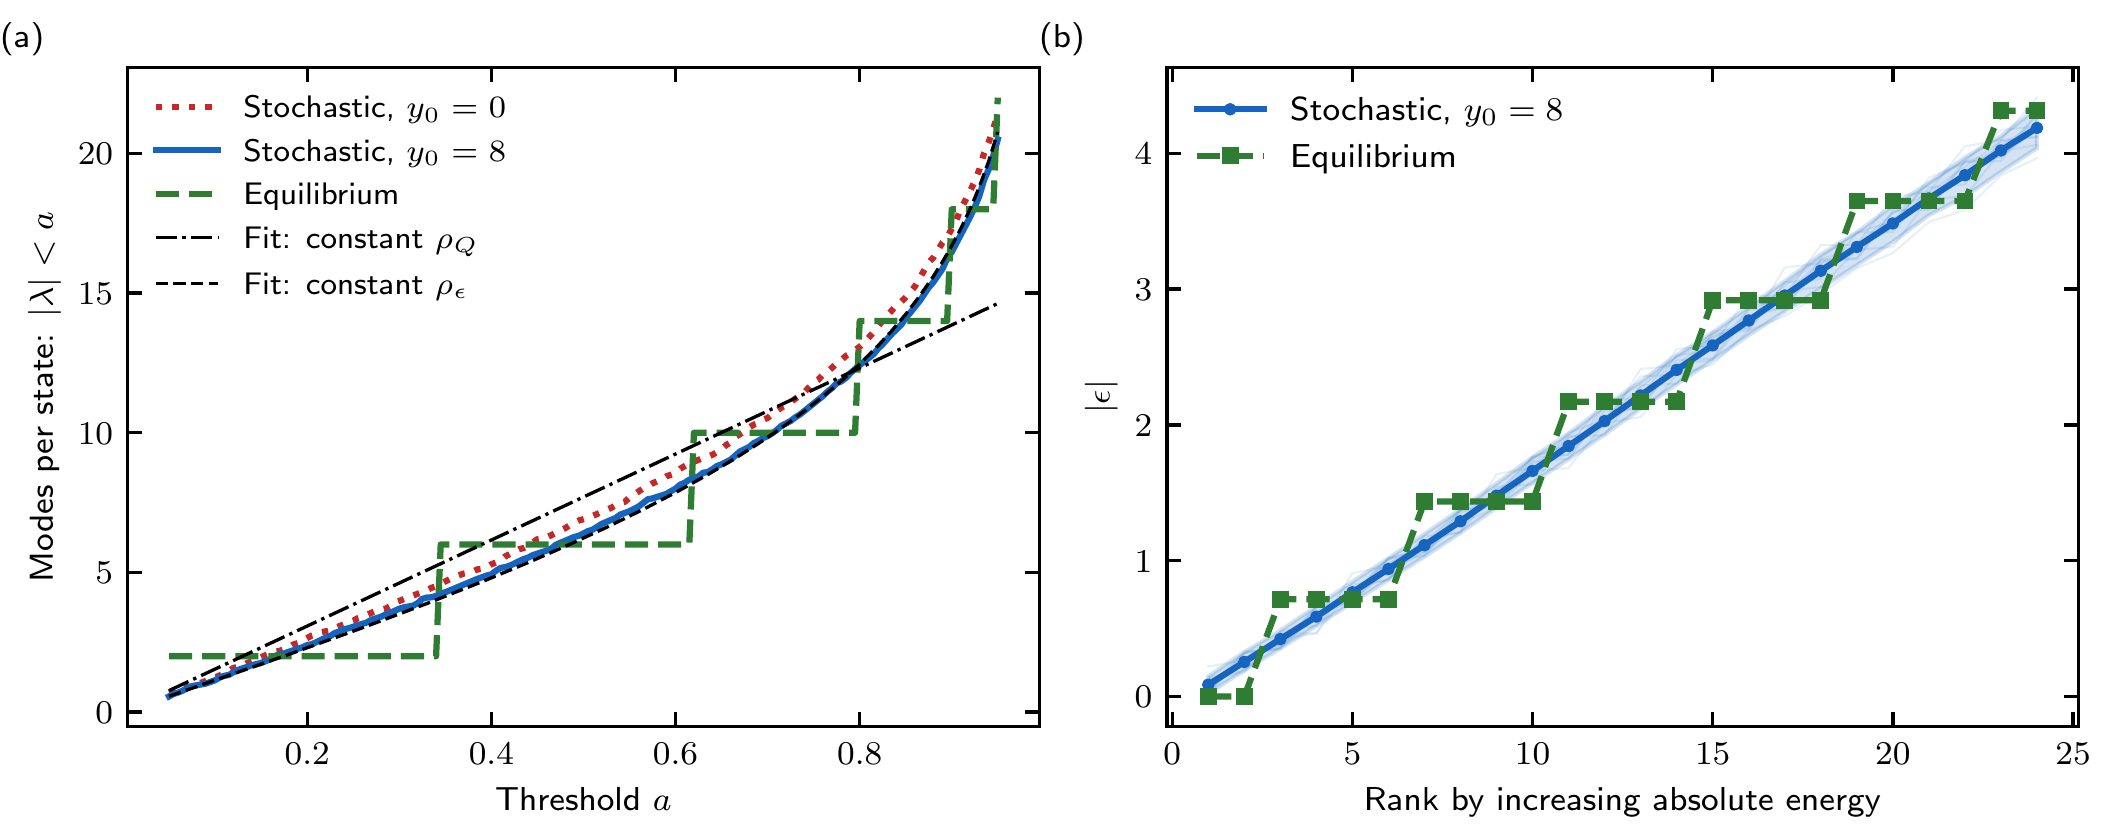

In [4]:
fig,axes=plt.subplots(1,2,figsize=(7.05,2.8));t=counts['cutoffs']
for key,name,color,style in [('stochastic_y0','Stochastic, $y_0=0$',RED,':'),('stochastic_y8','Stochastic, $y_0=8$',BLUE,'-'),('equilibrium','Equilibrium',GREEN,'--')]:
    axes[0].plot(t,counts[key],color=color,linestyle=style,label=name)
fit=pd.read_csv(OUT/'spectral_envelope_fits.csv')
for family,x,style,name in [('constant_lambda_density',t,'-.',r'Fit: constant $\rho_Q$'),('constant_epsilon_density',np.arctanh(t),'--',r'Fit: constant $\rho_\epsilon$')]:
    a=fit[(fit.protocol=='stochastic_y8')&(fit.model==family)].amplitude.iloc[0]
    axes[0].plot(t,a*x,color='black',linestyle=style,lw=.8,label=name)
axes[0].set(xlabel=r'Threshold $a$',ylabel=r'Modes per state: $|\lambda|<a$')
axes[0].legend(frameon=False,fontsize=7.5)
a=spatial['y8_spectra'];k=24
ordered=np.sort(abs(a),axis=1)[:,:k];energies=2*np.arctanh(ordered)
eq=2*np.arctanh(np.sort(abs(spatial['equilibrium_eigenvalues']))[:k])
r=np.arange(1,k+1)
for row in energies[:10]:axes[1].plot(r,row,color=BLUE,alpha=.1,lw=.5)
axes[1].fill_between(r,*np.quantile(energies,[.1,.9],axis=0),color=BLUE,alpha=.18)
axes[1].plot(r,energies.mean(0),'o-',color=BLUE,ms=2,label='Stochastic, $y_0=8$')
axes[1].plot(r,eq,'s--',color=GREEN,ms=3,label='Equilibrium')
axes[1].set(xlabel='Rank by increasing absolute energy',ylabel=r'$|\epsilon|$');axes[1].legend(frameon=False)
for ax,l in zip(axes,['(a)','(b)']):label(ax,l)
export(fig,'spectral_shape_and_level_splitting')

## Cut position and spatial origin of the excess
All 100 trajectories contribute at every origin in the first panel. A half cut and its complement have the same entropy, so only 16 inequivalent cuts are needed. The contour in the second panel is the additive Gaussian entropy contour of the full strip, integrated over the retained y rows and orbitals. It is not the entropy of an isolated x column. Error bars are trajectory SEM.

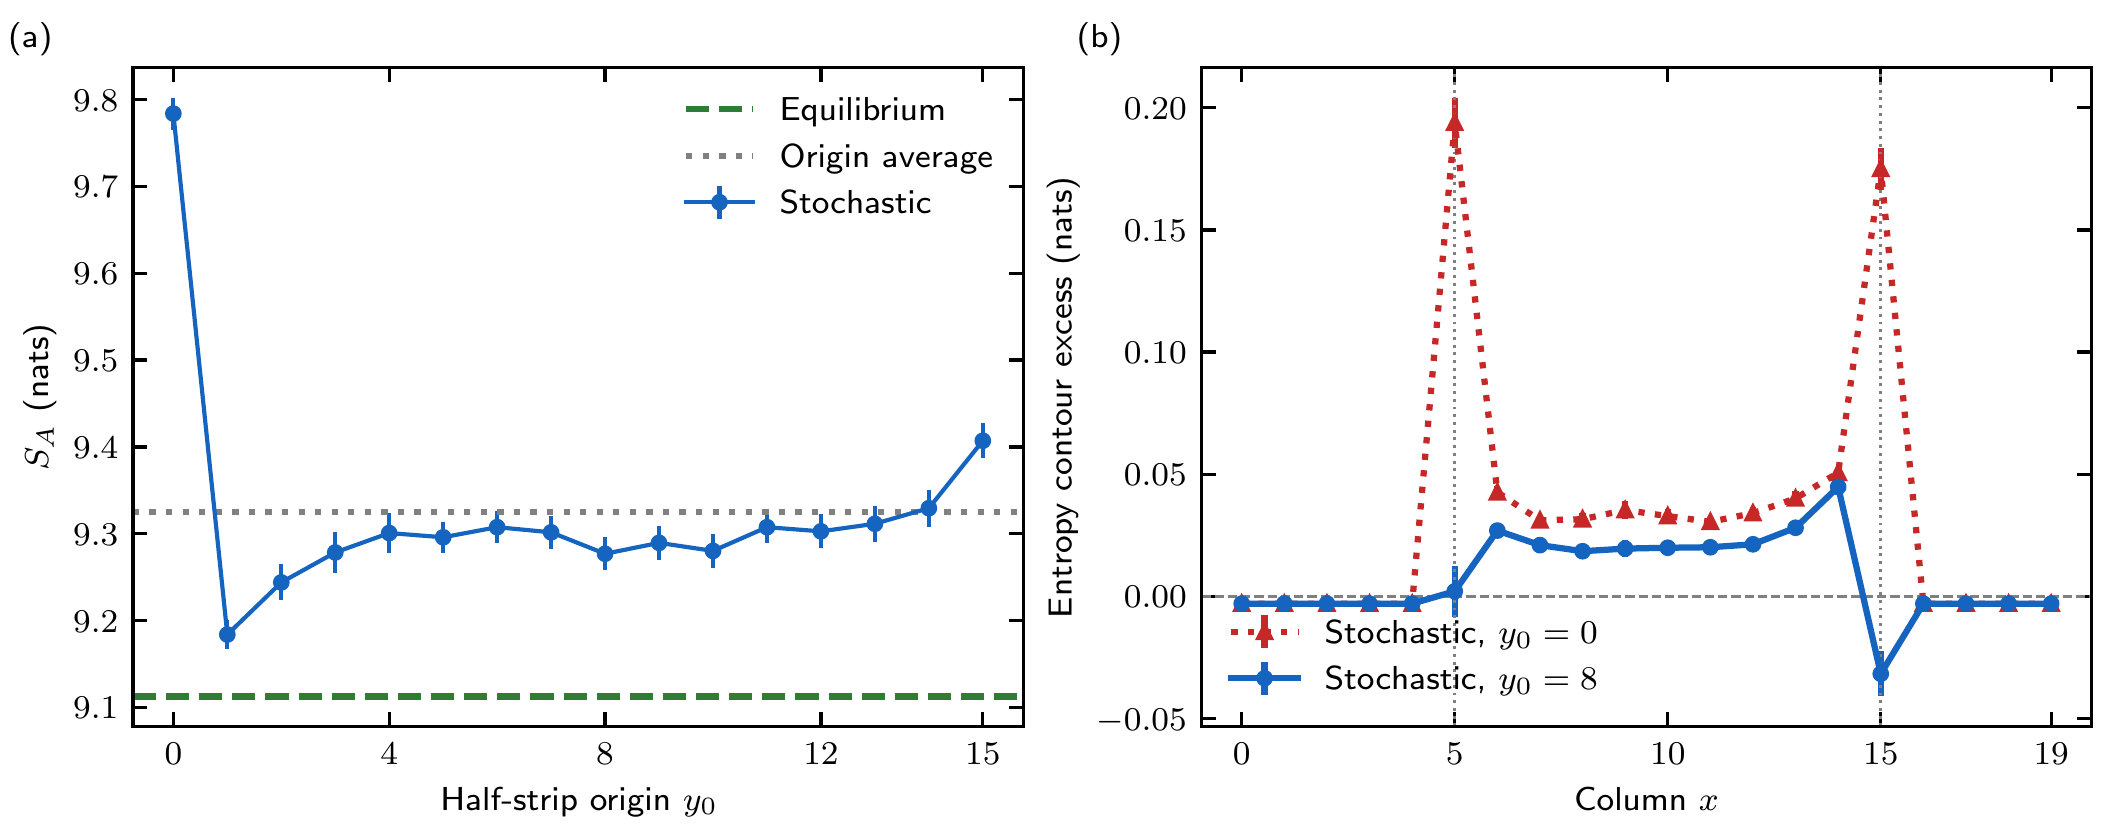

In [5]:
fig,axes=plt.subplots(1,2,figsize=(7.05,2.8))
m=metrics(spatial['origin_spectra'])['S1'];origin=np.arange(16)
axes[0].errorbar(origin,m.mean(0),yerr=m.std(0,ddof=1)/10,color=BLUE,marker='o',ms=3,lw=1,label='Stochastic')
axes[0].axhline(findings['equilibrium']['S1'],color=GREEN,ls='--',label='Equilibrium')
axes[0].axhline(m.mean(),color='gray',ls=':',label='Origin average')
axes[0].set(xlabel=r'Half-strip origin $y_0$',ylabel=r'$S_A$ (nats)',xticks=[0,4,8,12,15]);axes[0].legend(frameon=False)
x=np.arange(20)
for key,name,color,marker,style in [('entropy_x','Stochastic, $y_0=0$',RED,'^',':'),('entropy_x_y8','Stochastic, $y_0=8$',BLUE,'o','-')]:
    d=spatial[key]-spatial['equilibrium_entropy_x'][None,:]
    axes[1].errorbar(x,d.mean(0),yerr=d.std(0,ddof=1)/10,color=color,marker=marker,ls=style,ms=3,label=name)
axes[1].axhline(0,color='gray',ls='--',lw=.6)
for wall in [5,15]:axes[1].axvline(wall,color='gray',ls=':',lw=.7)
axes[1].set(xlabel=r'Column $x$',ylabel='Entropy contour excess (nats)',xticks=[0,5,10,15,19]);axes[1].legend(frameon=False)
for ax,l in zip(axes,['(a)','(b)']):label(ax,l)
export(fig,'cut_origin_and_spatial_excess')

## Size dependence and a shape diagnostic
Each stochastic point uses 100 trajectories. The origin-averaged points at $N_y=40,50,60$ use 20 trajectories, averaged over cuts before computing a trajectory SEM. The entropy fit uses $S_A=b+m\log N_y$ over all six sizes at fixed $N_x=20$; this is a finite-size comparison, not an independent universality-class determination. The two horizontal ratio references follow from ideal constant densities in the two different spectral variables.

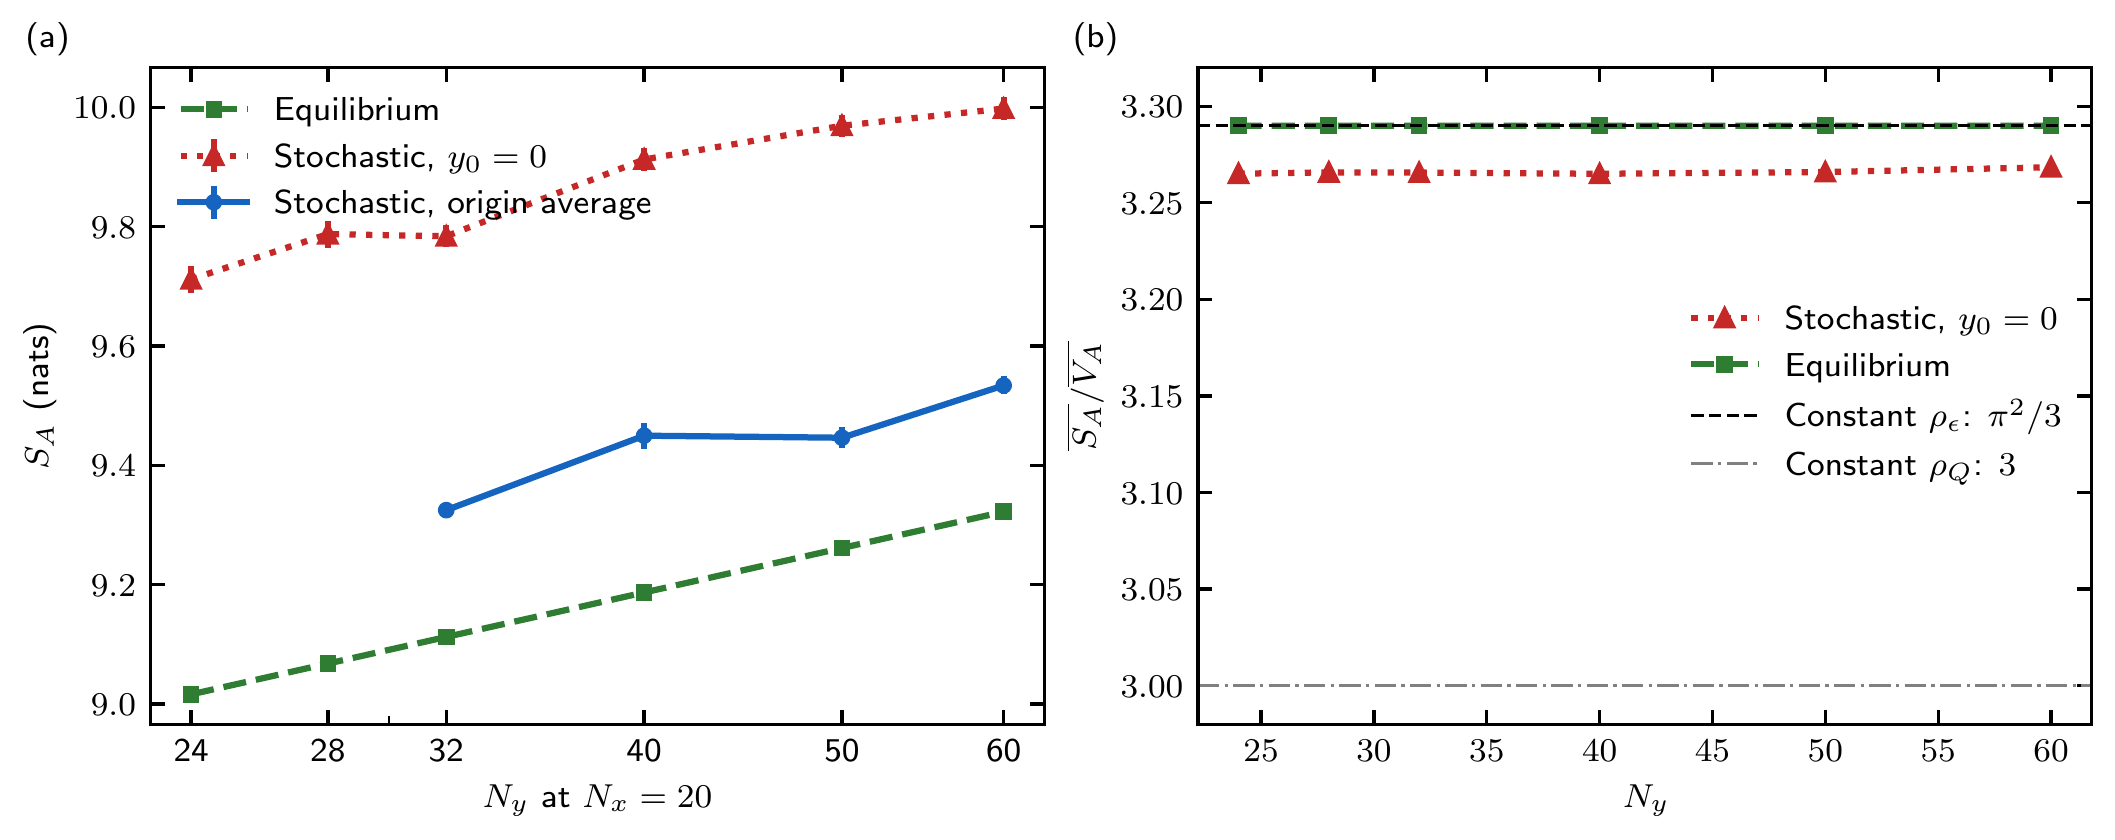

In [6]:
fig,axes=plt.subplots(1,2,figsize=(7.05,2.8))
s=size_table[size_table.protocol=='stochastic'];e=size_table[size_table.protocol=='equilibrium']
axes[0].errorbar(s.Ny,s.S1,yerr=s.S_sem,color=RED,marker='^',ls=':',ms=4,label=r'Stochastic, $y_0=0$')
axes[0].plot(e.Ny,e.S1,color=GREEN,marker='s',ls='--',ms=3,label='Equilibrium')
xs=[32,40,50,60];means=[findings['entropy_origins']['mean']];ses=[findings['entropy_origins']['sem']]
for ny in xs[1:]:
    v=metrics(large[f'origins_{ny}'])['S1'].mean(1);means.append(v.mean());ses.append(v.std(ddof=1)/np.sqrt(len(v)))
axes[0].errorbar(xs,means,yerr=ses,color=BLUE,marker='o',ls='-',ms=3,label='Stochastic, origin average')
axes[0].set_xscale('log');axes[0].set_xticks(sizes,labels=sizes);axes[0].xaxis.set_minor_formatter(mpl.ticker.NullFormatter())
axes[0].set(xlabel=r'$N_y$ at $N_x=20$',ylabel=r'$S_A$ (nats)');axes[0].legend(frameon=False)
axes[1].plot(s.Ny,s.S_over_V,color=RED,marker='^',ls=':',ms=4,label=r'Stochastic, $y_0=0$')
axes[1].plot(e.Ny,e.S_over_V,color=GREEN,marker='s',ls='--',ms=3,label='Equilibrium')
axes[1].axhline(np.pi**2/3,color='black',ls='--',lw=.8,label=r'Constant $\rho_\epsilon$: $\pi^2/3$')
axes[1].axhline(3,color='gray',ls='-.',lw=.8,label=r'Constant $\rho_Q$: $3$')
axes[1].set(xlabel=r'$N_y$',ylabel=r'$\overline{S_A}/\overline{V_A}$',ylim=(2.98,3.32));axes[1].legend(frameon=False,loc='center right')
for ax,l in zip(axes,['(a)','(b)']):label(ax,l)
export(fig,'size_scaling_and_entropy_variance')

## Saved partial-postselection evidence
This older control has Nx=20, Ny=40, 40 cycles, origin-averaged strip entropy and 10 trajectories for probabilities below one; full postselection has one deterministic trajectory. Its preparation/exterior protocol and cycle count differ from the main production ensemble, so it is shown as a separate within-campaign comparison. A final ten-cycle window is averaged inside each trajectory; temporal samples are not counted as independent.

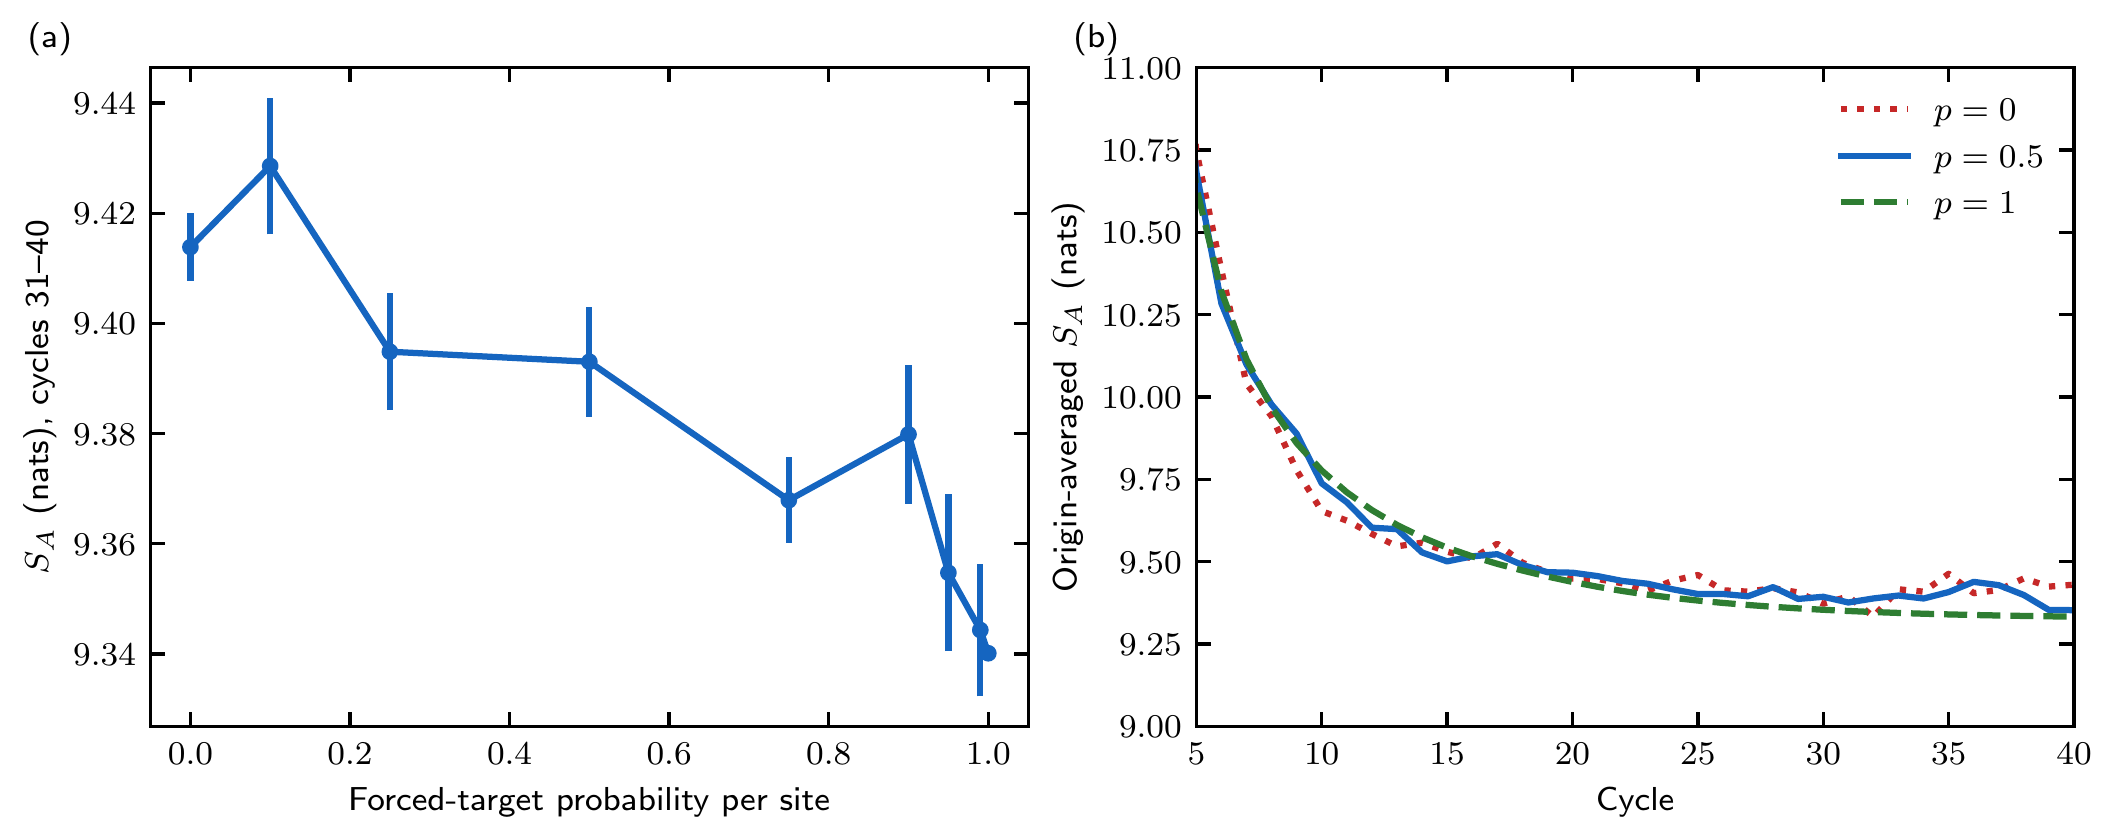

In [7]:
partial=pd.read_csv(OUT/'partial_postselection_entropy.csv')
fig,axes=plt.subplots(1,2,figsize=(7.05,2.8));rows=[]
for prob,g in partial.groupby('p'):
    late=g[g.cycle>=31].groupby('sample_id').S_half.mean()
    rows.append(dict(p=prob,S=late.mean(),sem=late.std(ddof=1)/np.sqrt(len(late)) if len(late)>1 else 0,samples=len(late)))
df=pd.DataFrame(rows)
axes[0].errorbar(df.p,df.S,yerr=df['sem'],color=BLUE,marker='o',ms=3,ls='-')
axes[0].set(xlabel='Forced-target probability per site',ylabel=r'$S_A$ (nats), cycles 31--40')
for prob,color,style in [(0.,RED,':'),(.5,BLUE,'-'),(1.,GREEN,'--')]:
    g=partial[partial.p==prob];piv=g.pivot(index='sample_id',columns='cycle',values='S_half')
    axes[1].plot(piv.columns,piv.mean(),color=color,ls=style,label=r'$p=%g$'%prob)
axes[1].set(xlim=(5,40),ylim=(9,11),xlabel='Cycle',ylabel=r'Origin-averaged $S_A$ (nats)');axes[1].legend(frameon=False)
for ax,l in zip(axes,['(a)','(b)']):label(ax,l)
df.to_csv(OUT/'partial_postselection_late_window.csv',index=False)
export(fig,'saved_partial_postselection_control')

## Ordered-measurement control, independent of Born randomness
One deterministic postselected trajectory starts from production sample 0's prepared active state. Its inactive product exterior is factored out and restored for observables. All stored checkpoints through cycle 32 pass purity, charge, and support checks. Later native-frame evolution amplifies inactive-row roundoff; those later snapshots are **excluded**, and no stationary postselected state is claimed.

Panel (a) subtracts each protocol's own origin-average entropy, isolating the cut-position pattern despite different final charge sectors. The comparison is stochastic cycle 64 versus deterministic cycle 32. Panel (b) subtracts the minimum active-region parent energy at each state's own active charge. Stochastic points use 100 trajectories; the deterministic point uses one prepared state and has no sampling error bar. This establishes finite-cycle protocol differences, not a noise-only causal decomposition.

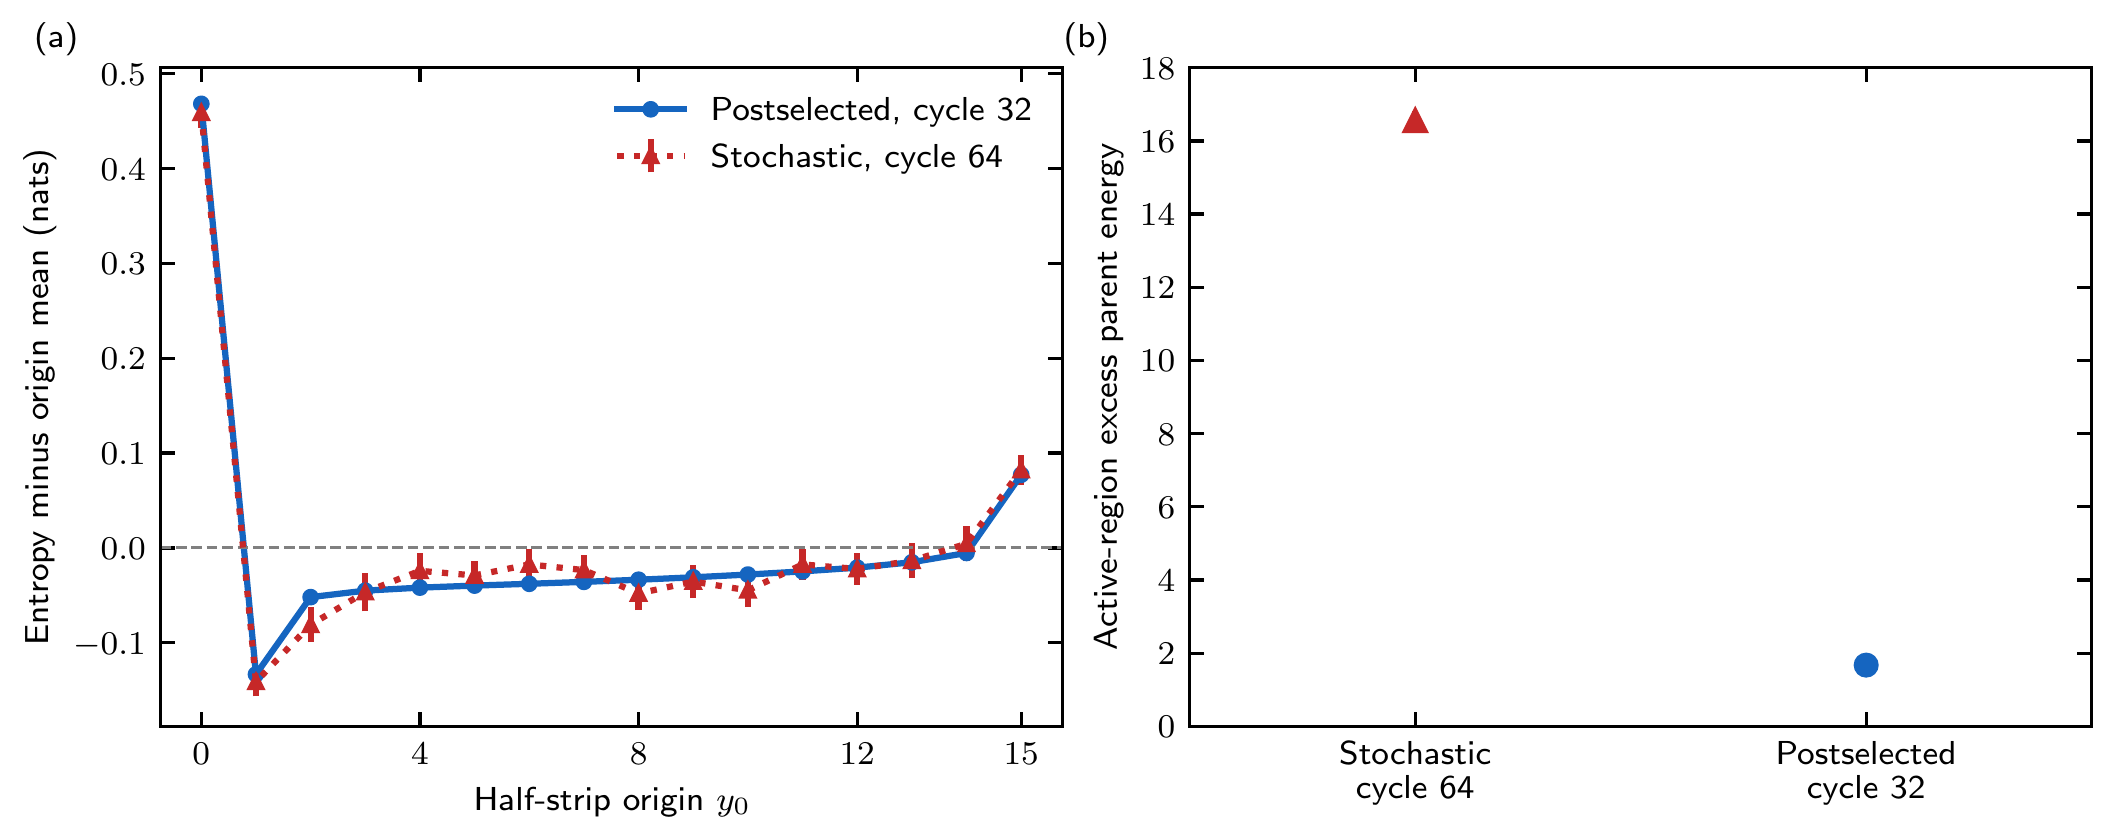

In [8]:
post=dict(np.load(OUT/'accepted_postselection_cycle32.npz'))
pm=metrics(post['spectra_32']);sm=metrics(spatial['origin_spectra'])
st=sm['S1']-sm['S1'].mean(1)[:,None];pp=pm['S1']-pm['S1'].mean()
fig,axes=plt.subplots(1,2,figsize=(7.05,2.8))
axes[0].errorbar(np.arange(16),st.mean(0),yerr=st.std(0,ddof=1)/10,color=RED,marker='^',ls=':',ms=3,label='Stochastic, cycle 64')
axes[0].plot(np.arange(16),pp,color=BLUE,marker='o',ls='-',ms=3,label='Postselected, cycle 32')
axes[0].axhline(0,color='gray',ls='--',lw=.7)
axes[0].set(xlabel=r'Half-strip origin $y_0$',ylabel='Entropy minus origin mean (nats)',xticks=[0,4,8,12,15]);axes[0].legend(frameon=False)
post_diag=json.loads((OUT/'factorized_postselection_progress.json').read_text())
pe=next(r['active_energy_excess'] for r in post_diag if r['cycle']==32)
se=findings['topological_excess_energy_same_rank']
axes[1].errorbar([0],[se['mean']],yerr=[se['sem']],color=RED,marker='^',ls='',ms=5)
axes[1].plot([1],[pe],color=BLUE,marker='o',ls='',ms=5)
axes[1].set(xticks=[0,1],xticklabels=['Stochastic\ncycle 64','Postselected\ncycle 32'],xlim=(-.5,1.5),ylim=(0,18),ylabel='Active-region excess parent energy')
for ax,l in zip(axes,['(a)','(b)']):label(ax,l)
pd.DataFrame({'origin':np.arange(16),'stochastic_delta_S':st.mean(0),'stochastic_sem':st.std(0,ddof=1)/10,'postselected_delta_S':pp}).to_csv(OUT/'ordered_protocol_cut_profile.csv',index=False)
export(fig,'ordered_protocol_control')

## Numerical diagnostics and limitations
Original production result checksums, bytes, receipts, configuration identities and unique sample IDs were validated in the companion scripts. The 40–60 occupation arrays were clipped by the acquisition observer; raw extrema were checked and representative frame-derived spectra reproduced those arrays. Matrices were checked before symmetrization, active frame columns alone were used, complementary entropies and contour closure were checked, and raw spectra were preserved.

The entropy of a Gaussian state reconstructed from the averaged two-point matrix is a different observable from the trajectory-averaged entanglement entropy. In particular, the inert exterior is a random product state in the stochastic preparation and a weakly entangled ground state in the full equilibrium benchmark. Neither its ensemble mixedness nor its large parent-energy cost should be presented as intrinsic wall entanglement.

The spatial and size evidence identifies cut dependence and level splitting, plus a residual entropy offset. It does not establish a distinct universal spectral law, a new central charge, or a causal separation of stochastic noise from ordered noncommuting measurements. The matched postselection control is documented separately when complete.

In [9]:
display(pd.read_csv(OUT/'spectral_envelope_fits.csv'))
print(json.dumps(findings,indent=2))
for f in tqdm(sorted(OUT.glob('*.npz')),desc='Check finite scientific arrays'):
    with np.load(f) as z:
        for key in z.files:
            a=z[key]
            if a.dtype.kind in 'fc':
                assert np.isfinite(a).all(), (f.name,key)
print('All displayed arrays finite. Figure files:',[f.name for f in OUT.glob('*.pdf')])

,protocol,model,amplitude,rmse_levels,fit_min,fit_max,fit_points
0,stochastic_y0,constant_lambda_density,16.346611,1.416364,0.05,0.95,181
1,stochastic_y0,constant_epsilon_density,12.020085,0.232726,0.05,0.95,181
2,stochastic_y8,constant_lambda_density,15.397531,1.403677,0.05,0.95,181
3,stochastic_y8,constant_epsilon_density,11.338012,0.150864,0.05,0.95,181
4,stochastic_origin_average,constant_lambda_density,15.495760,1.404971,0.05,0.95,181
5,stochastic_origin_average,constant_epsilon_density,11.408701,0.154975,0.05,0.95,181
6,equilibrium,constant_lambda_density,14.935963,1.835342,0.05,0.95,181
7,equilibrium,constant_epsilon_density,11.019536,1.119033,0.05,0.95,181


{
  "size_fits": [
    {
      "protocol": "stochastic",
      "Ny_min": 24,
      "Ny_max": 60,
      "intercept": 8.689958366463543,
      "slope": 0.32376037617007114,
      "slope_sem": 0.025594528018759853,
      "chi_squared": 6.64154425521509,
      "dof": 4
    },
    {
      "protocol": "equilibrium",
      "Ny_min": 24,
      "Ny_max": 60,
      "intercept": 7.955157606248025,
      "slope": 0.3339344849100597,
      "slope_sem": null
    }
  ],
  "level_gap_diagnostics": {
    "stochastic_y0": {
      "window": "abs(epsilon)<3",
      "gaps": 1661,
      "median": 0.3402912177485198,
      "fraction_below_1e_minus5": 0.0
    },
    "stochastic_y8": {
      "window": "abs(epsilon)<3",
      "gaps": 1578,
      "median": 0.35721846911836,
      "fraction_below_1e_minus5": 0.0
    },
    "stochastic_origin_average": {
      "window": "abs(epsilon)<3",
      "gaps": 25369,
      "median": 0.35698793014600105,
      "fraction_below_1e_minus5": 0.0
    },
    "equilibrium": {
    

Check finite scientific arrays:   0%|          | 0/12 [00:00<?, ?it/s]

All displayed arrays finite. Figure files: ['saved_partial_postselection_control.pdf', 'spectral_shape_and_level_splitting.pdf', 'ordered_protocol_control.pdf', 'cut_origin_and_spatial_excess.pdf', 'matched_normalized_densities.pdf', 'size_scaling_and_entropy_variance.pdf']
